# Part 1: Deep Learning for Corporate Finance - Results Visualization

This notebook loads trained model checkpoints and generates all figures for the report.

**Prerequisites:** Run `01_part1_training.ipynb` first to generate checkpoints.

**Output:** All figures are saved to `results/latest/figures/`

In [1]:
# =============================================================================
# 1.1 Imports and Configuration
# =============================================================================

import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob

# Add project root to path
sys.path.insert(0, os.path.abspath(".."))

# Utility imports
from src.utils.checkpointing import load_training_result
from src.utils.analysis import (
    get_steady_state_policy, 
    evaluate_policy, 
    compute_frictionless_policy,
    print_training_summary
)
from src.utils.plotting import (
    plot_basic_loss_curves,
    plot_risky_loss_curves,
    plot_policy_slices_compare_overlay,
    plot_scenario_comparison_panels,
    plot_policy_slices_single,
    plot_3d_policy_slice,
    plot_3d_policy_panels
)
from src.economy.parameters import EconomicParams, ShockParams

print("All imports successful!")

All imports successful!


/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# =============================================================================
# 1.2 Load Configuration from Latest Run
# =============================================================================

# Use 'latest' symlink for stable path (points to most recent training run)
RESULTS_BASE = os.path.join("..", "results")
RESULTS_DIR = os.path.join(RESULTS_BASE, "latest")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
CHECKPOINTS_DIR = os.path.join(RESULTS_DIR, "checkpoints")

# Verify paths exist
if not os.path.exists(RESULTS_DIR):
    raise FileNotFoundError(
        f"Results directory not found: {RESULTS_DIR}\n"
        "Please run 01_part1_training.ipynb first to generate checkpoints."
    )

# Resolve symlink to show actual run name
if os.path.islink(RESULTS_DIR):
    actual_run = os.readlink(RESULTS_DIR)
    print(f"Loading results from: {RESULTS_DIR} -> {actual_run}")
else:
    print(f"Loading results from: {RESULTS_DIR}")

# Ensure figures directory exists
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIGURES_DIR}")

Loading results from: ../results/latest -> run-20260211-224035
Figures will be saved to: ../results/latest/figures


In [3]:
# =============================================================================
# 1.3 Load Scenario Metadata
# =============================================================================

# Load scenario definitions
scenarios_path = os.path.join(CHECKPOINTS_DIR, 'scenarios.json')
with open(scenarios_path, 'r') as f:
    scenarios_meta = json.load(f)

basic_scenarios = scenarios_meta['basic_scenarios']
risky_scenarios = scenarios_meta['risky_scenarios']
methods_meta_raw = scenarios_meta.get('methods', [])

# Normalize legacy/canonical method ids to a stable notebook-facing set
method_aliases = {
    'basic_lr': 'lr',
    'basic_er': 'er',
    'basic_br_actor_critic': 'br',
    'basic_br_multitask': 'br_multitask',
    'br_reg': 'br_multitask',
}

methods_meta = [method_aliases.get(m, m) for m in methods_meta_raw]
methods_meta = list(dict.fromkeys(methods_meta))  # preserve order, drop duplicates

preferred_methods = ['lr', 'er', 'br', 'br_multitask']
methods = [m for m in preferred_methods if m in methods_meta]
methods += [m for m in methods_meta if m not in methods]

# Directory fallback rules for backward compatibility
method_checkpoint_candidates = {
    'br_multitask': ['br_multitask', 'br_reg'],
}

# Optional auto-detect when metadata is older/incomplete
if len(basic_scenarios) > 0:
    probe_scenario = basic_scenarios[0]
    probe_base = os.path.join(CHECKPOINTS_DIR, 'basic', probe_scenario)

    if 'br_multitask' not in methods:
        for candidate in method_checkpoint_candidates['br_multitask']:
            if os.path.isdir(os.path.join(probe_base, candidate)):
                methods.append('br_multitask')
                print(f"Detected BR-multitask checkpoints in {probe_scenario}; appended 'br_multitask' to methods.")
                break

print(f"Scenarios loaded:")
print(f"  Basic: {basic_scenarios}")
print(f"  Risky: {risky_scenarios}")
print(f"  Methods: {methods}")

# Load bounds
bounds_path = os.path.join(CHECKPOINTS_DIR, 'bounds.json')
with open(bounds_path, 'r') as f:
    bounds_loaded = json.load(f)

k_bounds = tuple(bounds_loaded['k'])
logz_bounds = tuple(bounds_loaded['log_z'])
b_bounds = tuple(bounds_loaded['b'])

print(f"\nBounds loaded: k={k_bounds}, log_z={logz_bounds}, b={b_bounds}")



Scenarios loaded:
  Basic: ['baseline', 'smooth_cost', 'fixed_cost']
  Risky: ['baseline']
  Methods: ['lr', 'er', 'br', 'br_reg']

Bounds loaded: k=(15.447022976557044, 308.94045953114085), log_z=(-0.6301260378126043, 0.6301260378126043), b=(0.0, 188.9954691887226)


In [4]:
# =============================================================================
# 1.4 Load All Training Results
# =============================================================================

# Load basic model results
print("=" * 70)
print("LOADING BASIC MODEL RESULTS")
print("=" * 70)

results_basic = {}
for scenario_name in basic_scenarios:
    results_basic[scenario_name] = {}
    print(f"\nScenario: {scenario_name}")

    for method_name in methods:
        candidates = method_checkpoint_candidates.get(method_name, [method_name])
        checkpoint_dir = None
        selected_candidate = None

        for candidate in candidates:
            trial_dir = os.path.join(CHECKPOINTS_DIR, "basic", scenario_name, candidate)
            if os.path.isdir(trial_dir):
                checkpoint_dir = trial_dir
                selected_candidate = candidate
                break

        if checkpoint_dir is None:
            raise FileNotFoundError(
                f"Could not find checkpoint for method='{method_name}' in scenario='{scenario_name}'. "
                f"Tried: {candidates}"
            )

        result = load_training_result(checkpoint_dir, verbose=False)
        results_basic[scenario_name][method_name] = result

        if selected_candidate != method_name:
            print(f"  Loaded {method_name} (from legacy dir '{selected_candidate}')")
        else:
            print(f"  Loaded {method_name}")

# Load risky model results
print("\n" + "=" * 70)
print("LOADING RISKY DEBT RESULTS")
print("=" * 70)

results_risky = {}
for scenario_name in risky_scenarios:
    checkpoint_dir = os.path.join(CHECKPOINTS_DIR, "risky", scenario_name)
    result = load_training_result(checkpoint_dir, verbose=False)
    results_risky[scenario_name] = result
    print(f"  Loaded {scenario_name}")

print(f"\nLoaded {len(basic_scenarios) * len(methods)} basic + {len(risky_scenarios)} risky results.")


2026-02-12 09:52:23.273137: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-02-12 09:52:23.273166: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-12 09:52:23.273172: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-12 09:52:23.273188: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-12 09:52:23.273202: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


LOADING BASIC MODEL RESULTS

Scenario: baseline
  Loaded lr
  Loaded er
  Loaded br
  Loaded br_reg

Scenario: smooth_cost
  Loaded lr
  Loaded er
  Loaded br
  Loaded br_reg

Scenario: fixed_cost
  Loaded lr
  Loaded er
  Loaded br
  Loaded br_reg

LOADING RISKY DEBT RESULTS
  Loaded baseline

Loaded 12 basic + 1 risky results.


## 2. Basic Model Analysis

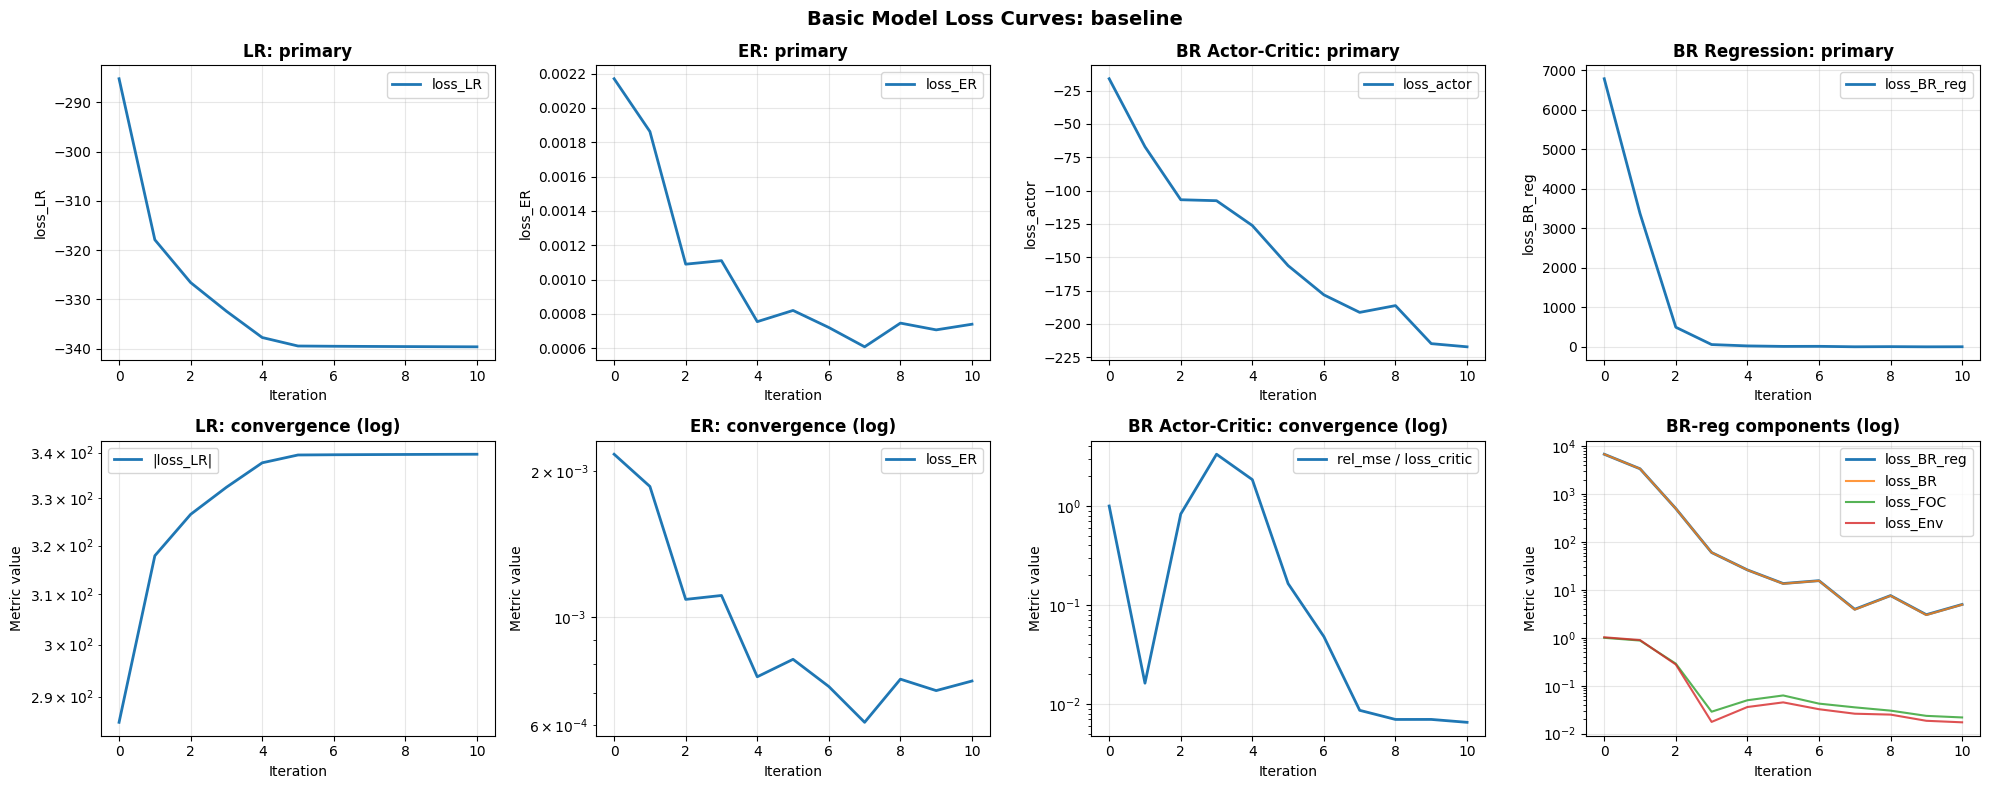

Saved: basic_loss_curves_baseline.png


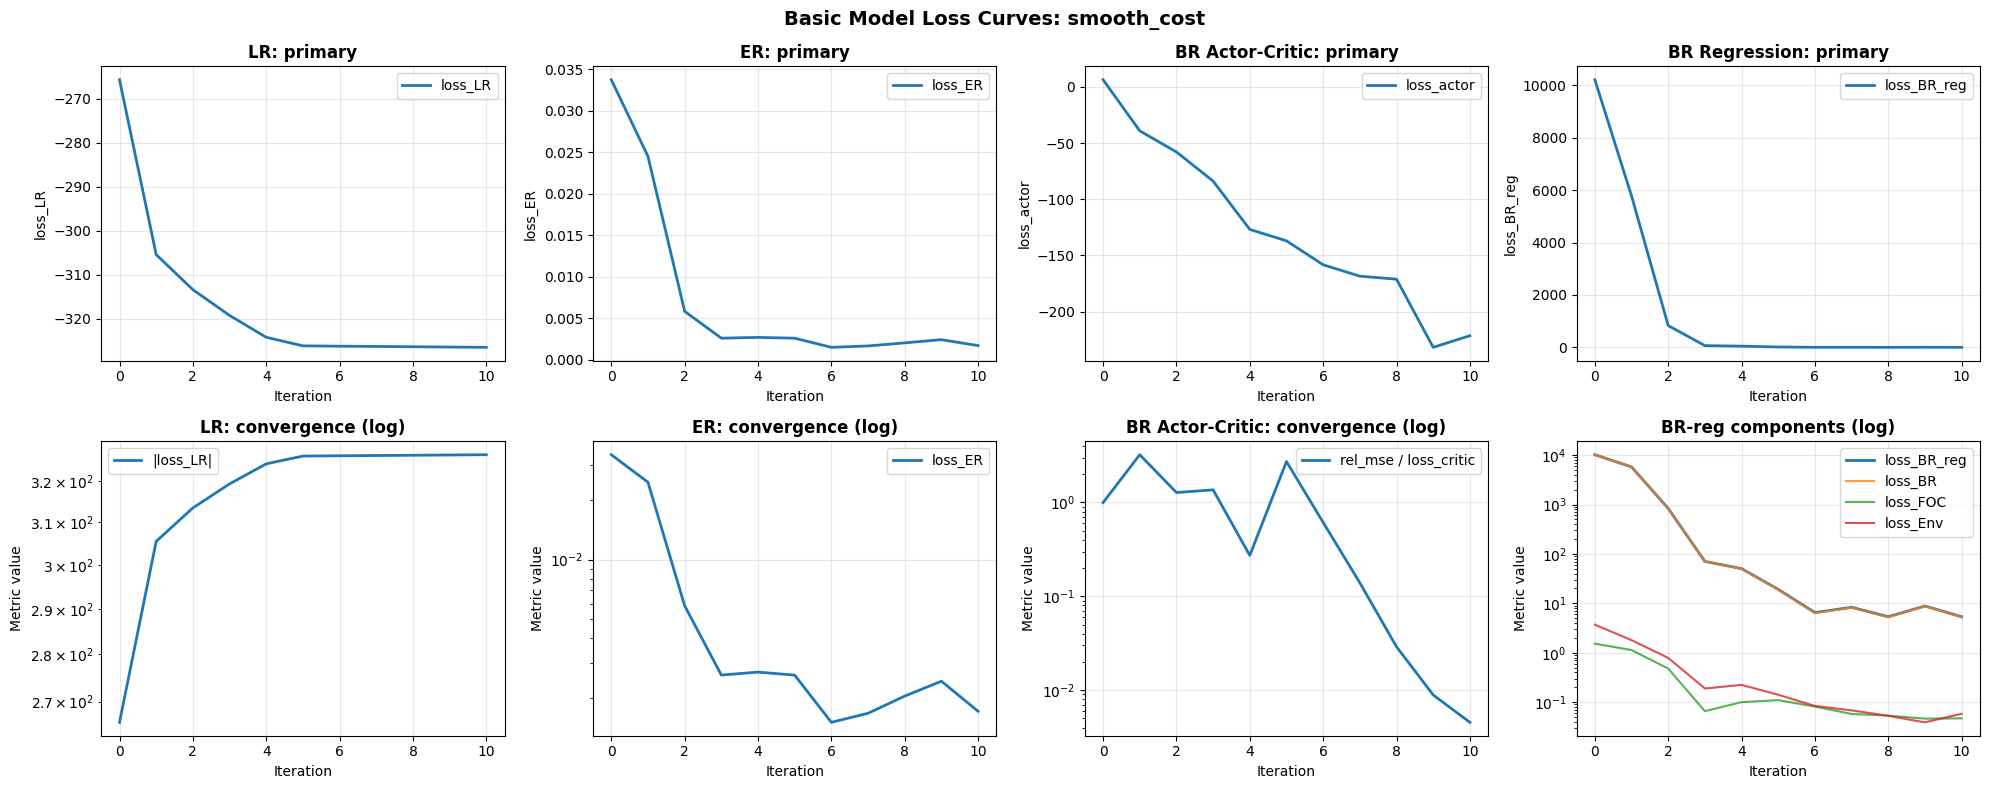

Saved: basic_loss_curves_smooth_cost.png


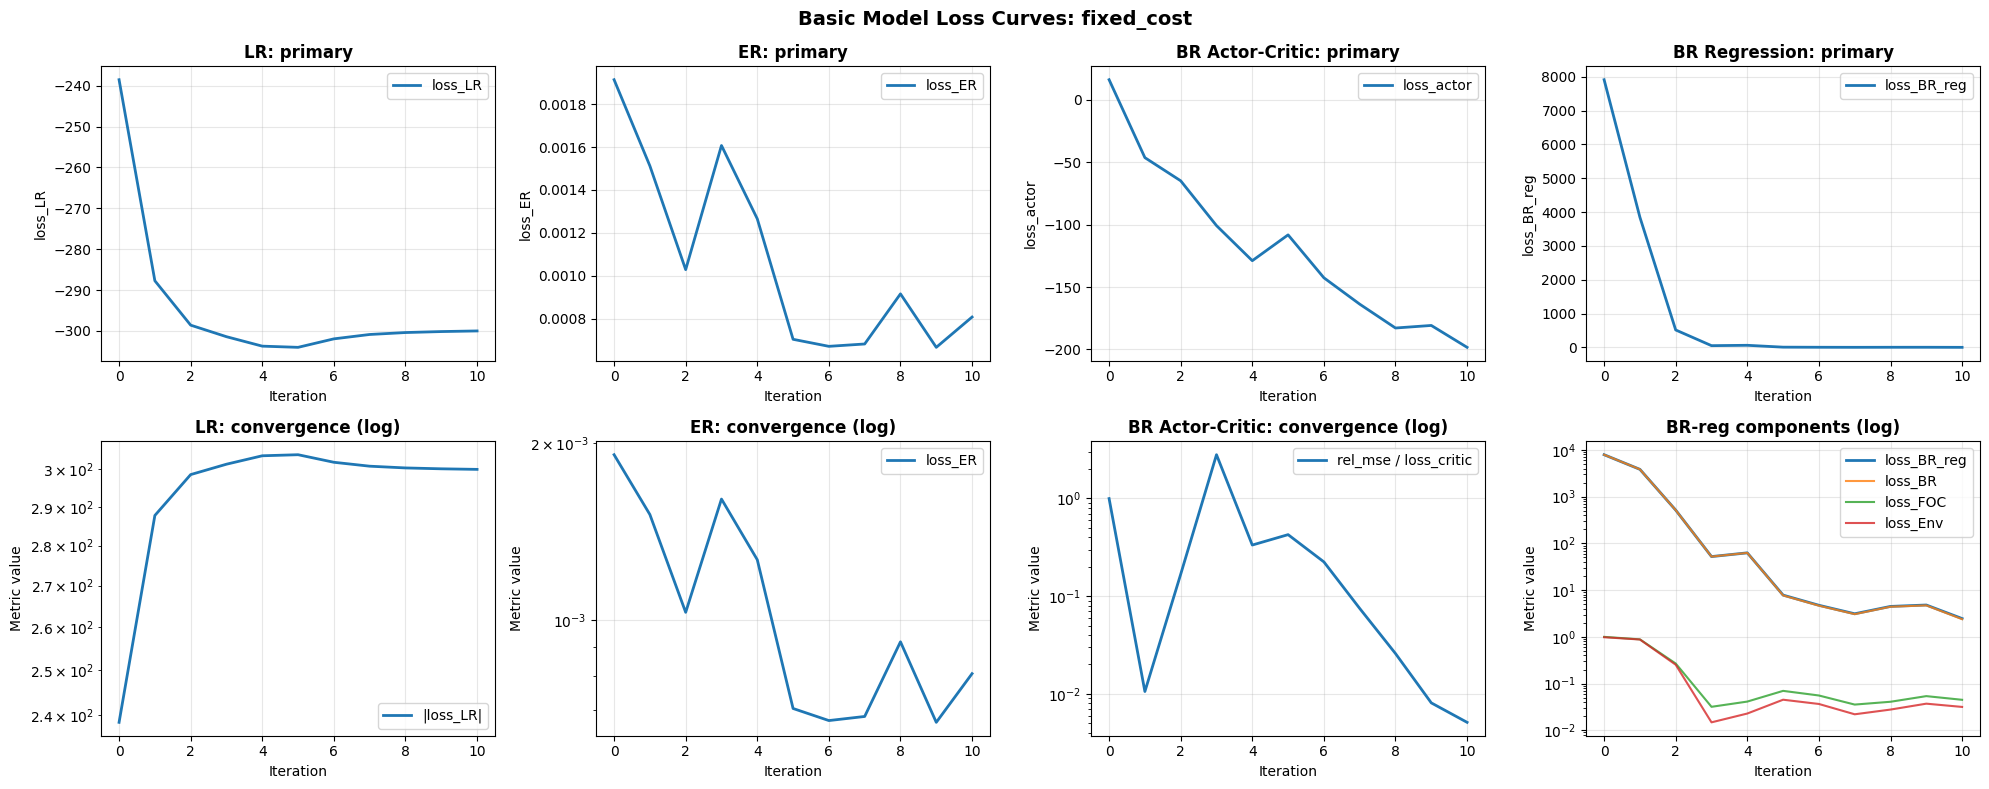

Saved: basic_loss_curves_fixed_cost.png


In [5]:
# =============================================================================
# 3.4.1 Per-Scenario Loss Curves (LR / ER / BR variants)
# =============================================================================

method_order = [m for m in ['lr', 'er', 'br', 'br_multitask'] if m in methods]
method_labels = {
    'lr': 'LR',
    'er': 'ER',
    'br': 'BR Actor-Critic',
    'br_multitask': 'BR Multitask',
}


def _series(history, *keys):
    for key in keys:
        if key in history and len(history[key]) > 0:
            return np.asarray(history[key], dtype=float)
    return None


for scenario_name in basic_scenarios:
    scenario_results = results_basic[scenario_name]
    n_cols = len(method_order)
    fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8), squeeze=False)

    for col, method_name in enumerate(method_order):
        result = scenario_results[method_name]
        history = result['history']

        if method_name == 'lr':
            y_primary = _series(history, 'loss_LR')
            y_conv = np.abs(y_primary) if y_primary is not None else None
            primary_label = 'loss_LR'
            conv_label = '|loss_LR|'
        elif method_name == 'er':
            y_primary = _series(history, 'loss_ER')
            y_conv = y_primary
            primary_label = 'loss_ER'
            conv_label = 'loss_ER'
        elif method_name == 'br':
            y_primary = _series(history, 'loss_critic')
            y_conv = _series(history, 'loss_actor')
            primary_label = 'loss_critic'
            conv_label = 'loss_actor'
        else:  # br_multitask
            y_primary = _series(history, 'loss_BR_reg')
            y_conv = _series(history, 'loss_BR_reg')
            primary_label = 'loss_BR_reg'
            conv_label = 'loss_BR_reg'

        if y_primary is None:
            raise KeyError(f"Missing primary loss series for method={method_name}, scenario={scenario_name}")

        x_primary = np.arange(len(y_primary))

        # Top row: primary objective
        axes[0, col].plot(x_primary, y_primary, linewidth=2, label=primary_label)
        axes[0, col].set_title(f"{method_labels.get(method_name, method_name)}: primary", fontweight='bold')
        axes[0, col].set_xlabel('Iteration')
        axes[0, col].set_ylabel(primary_label)
        axes[0, col].grid(True, alpha=0.3)
        axes[0, col].legend()

        # Bottom row: method-specific convergence/components (log scale)
        if method_name == 'br_multitask':
            y_br = _series(history, 'loss_BR')
            y_foc = _series(history, 'loss_FOC')
            y_env = _series(history, 'loss_Env')

            axes[1, col].plot(x_primary, np.maximum(y_primary, 1e-12), linewidth=2, label=primary_label)
            if y_br is not None:
                axes[1, col].plot(np.arange(len(y_br)), np.maximum(y_br, 1e-12), linewidth=1.5, label='loss_BR', alpha=0.8)
            if y_foc is not None:
                axes[1, col].plot(np.arange(len(y_foc)), np.maximum(y_foc, 1e-12), linewidth=1.5, label='loss_FOC', alpha=0.8)
            if y_env is not None:
                axes[1, col].plot(np.arange(len(y_env)), np.maximum(y_env, 1e-12), linewidth=1.5, label='loss_Env', alpha=0.8)

            axes[1, col].set_title(f"{method_labels.get(method_name, method_name)} components (log)", fontweight='bold')
        else:
            if y_conv is None:
                raise KeyError(f"Missing convergence series for method={method_name}, scenario={scenario_name}")
            x_conv = np.arange(len(y_conv))
            axes[1, col].plot(x_conv, np.maximum(y_conv, 1e-12), linewidth=2, label=conv_label)
            axes[1, col].set_title(f"{method_labels.get(method_name, method_name)}: convergence (log)", fontweight='bold')

        axes[1, col].set_xlabel('Iteration')
        axes[1, col].set_ylabel('Metric value')
        axes[1, col].set_yscale('log')
        axes[1, col].grid(True, alpha=0.3)
        axes[1, col].legend()

    fig.suptitle(f"Basic Model Loss Curves: {scenario_name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, f"basic_loss_curves_{scenario_name}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {os.path.basename(save_path)}")



In [6]:
# =============================================================================
# 3.4.2 Cross-Scenario Summary Table
# =============================================================================

method_labels = {
    'lr': 'LR',
    'er': 'ER',
    'br': 'BR-AC',
    'br_multitask': 'BR-MT',
}

summary_data = []
for scenario_name in basic_scenarios:
    scenario_results = results_basic[scenario_name]

    for method_name in methods:
        result = scenario_results[method_name]
        history = result['history']

        if method_name == 'lr':
            final_loss = history['loss_LR'][-1]
            loss_name = 'loss_LR'
        elif method_name == 'er':
            final_loss = history['loss_ER'][-1]
            loss_name = 'loss_ER'
        elif method_name == 'br':
            final_loss = history['loss_critic'][-1]
            loss_name = 'loss_critic'
        else:  # br_multitask
            final_loss = history['loss_BR_reg'][-1]
            loss_name = 'loss_BR_reg'

        summary_data.append({
            'Scenario': scenario_name,
            'Method': method_labels.get(method_name, method_name.upper()),
            'Final Metric': final_loss,
            'Metric Name': loss_name,
            'loss_BR': history.get('loss_BR', [np.nan])[-1],
            'loss_FOC': history.get('loss_FOC', [np.nan])[-1],
            'loss_Env': history.get('loss_Env', [np.nan])[-1],
        })

summary_df = pd.DataFrame(summary_data)

print("\nDetailed Summary (tail):")
print(summary_df.tail(15).to_string(index=False))

pivot_df = summary_df.pivot(index='Scenario', columns='Method', values='Final Metric')
print("\nPivot Table (Method-specific final metric):")
print(pivot_df.to_string())




Detailed Summary (tail):
   Scenario Method  Final Metric Metric Name  loss_BR  loss_FOC  loss_Env
   baseline     LR   -339.649841     loss_LR      NaN       NaN       NaN
   baseline     ER      0.000740     loss_ER      NaN       NaN       NaN
   baseline  BR-AC      0.006541     rel_mse      NaN       NaN       NaN
   baseline BR-Reg      4.971539 loss_BR_reg 4.932510  0.021790  0.017238
smooth_cost     LR   -326.522522     loss_LR      NaN       NaN       NaN
smooth_cost     ER      0.001718     loss_ER      NaN       NaN       NaN
smooth_cost  BR-AC      0.004546     rel_mse      NaN       NaN       NaN
smooth_cost BR-Reg      5.337603 loss_BR_reg 5.232550  0.046938  0.058114
 fixed_cost     LR   -300.022064     loss_LR      NaN       NaN       NaN
 fixed_cost     ER      0.000809     loss_ER      NaN       NaN       NaN
 fixed_cost  BR-AC      0.005110     rel_mse      NaN       NaN       NaN
 fixed_cost BR-Reg      2.465117 loss_BR_reg 2.388525  0.044951  0.031641

Pivot Table


Scenario: baseline
Loaded params: cost_convex=0.0, cost_fixed=0.0
Steady State Capital (k*):
  lr: 77.4159
  er: 86.0158
  br: 118.6515
  br_reg: 89.1644


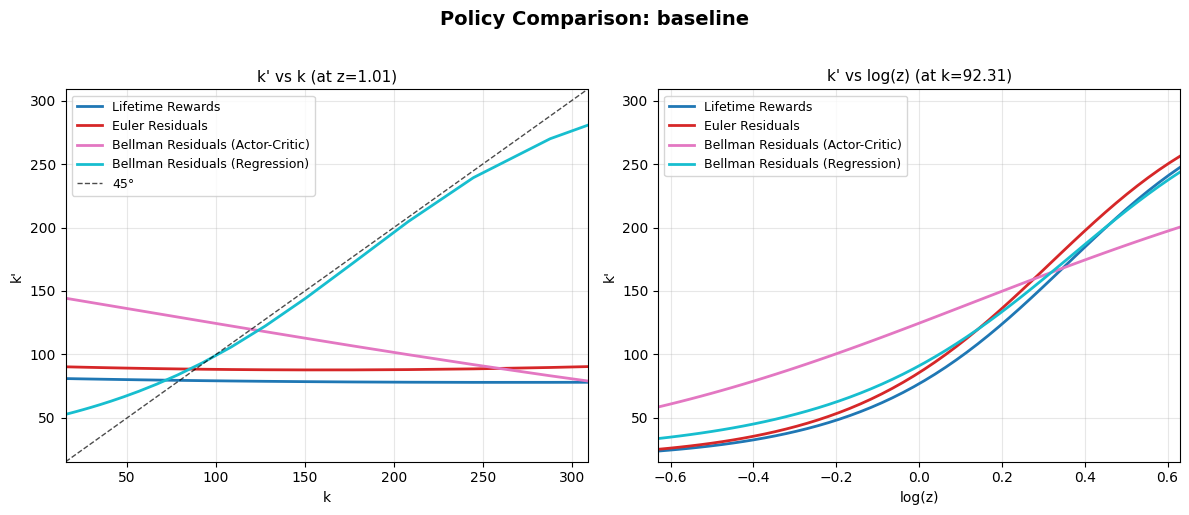

Reference k used for all overlays: k*(br_reg) = 89.1644

Scenario: smooth_cost
Loaded params: cost_convex=0.2, cost_fixed=0.0
Steady State Capital (k*):
  lr: 72.3854
  er: 81.5129
  br: 91.3098
  br_reg: 49.6218


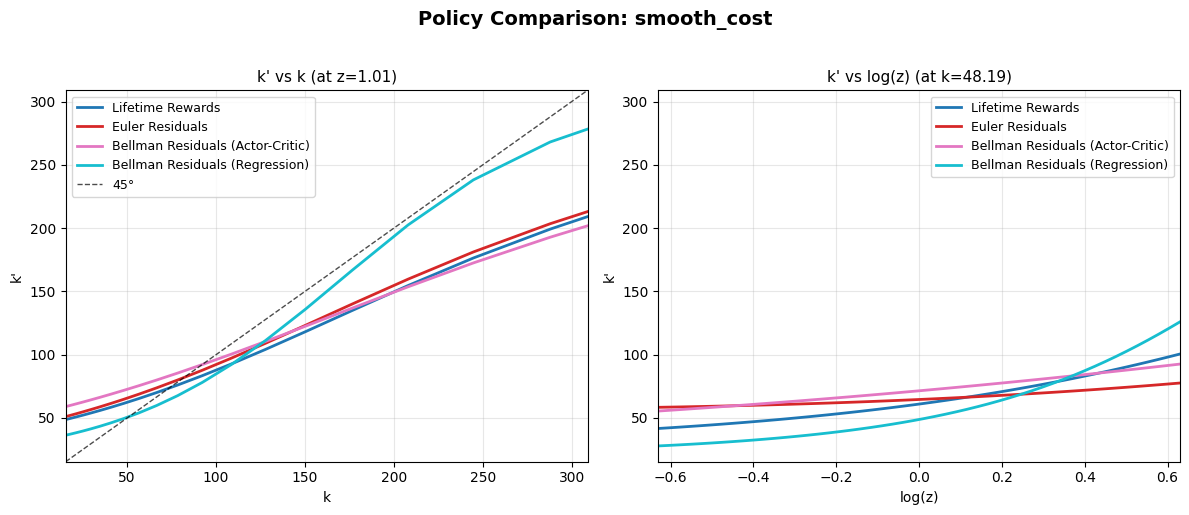

Reference k used for all overlays: k*(br_reg) = 49.6218

Scenario: fixed_cost
Loaded params: cost_convex=0.0, cost_fixed=0.02
Steady State Capital (k*):
  lr: 54.6164
  er: 88.7898
  br: 68.1412
  br_reg: 89.7984


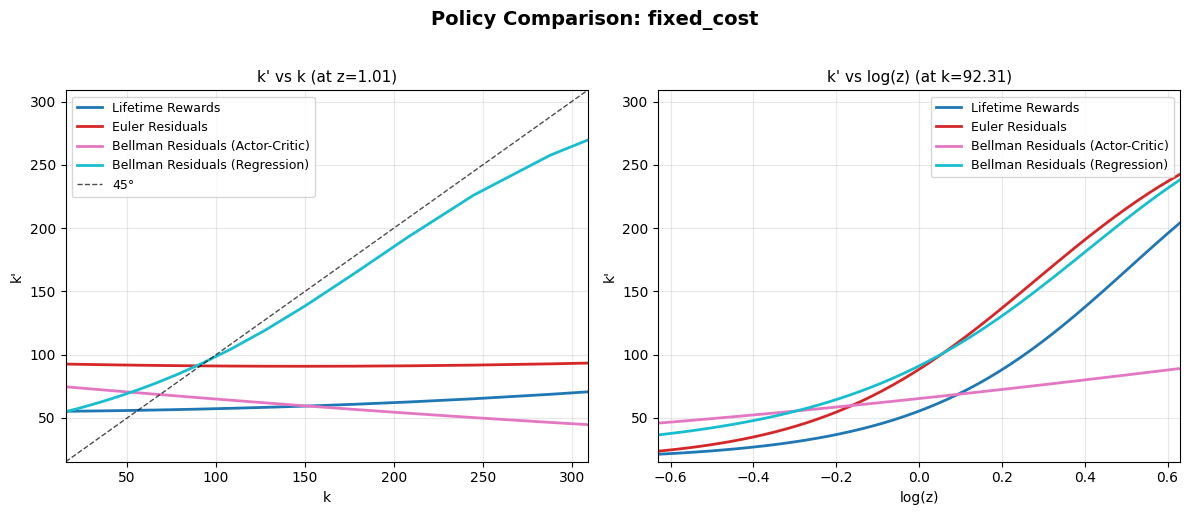

Reference k used for all overlays: k*(br_reg) = 89.7984


In [7]:
# =============================================================================
# 3.4.3 Per-Scenario Policy Comparison (LR vs ER vs BR variants)
# =============================================================================

from src.utils.analysis import get_steady_state_policy, evaluate_policy
from src.utils.plotting import plot_policy_slices_compare_overlay

method_order = [m for m in ['lr', 'er', 'br', 'br_multitask'] if m in methods]
method_labels = {
    'lr': 'Lifetime Rewards',
    'er': 'Euler Residuals',
    'br': 'Bellman Residuals (Actor-Critic)',
    'br_multitask': 'Bellman Residuals (Multitask)',
}

for scenario_name in basic_scenarios:
    print(f"\n{'=' * 60}")
    print(f"Scenario: {scenario_name}")
    print(f"{'=' * 60}")

    scenario_results = results_basic[scenario_name]

    # Load params that were used during training for this scenario
    params_path = os.path.join(CHECKPOINTS_DIR, "basic", scenario_name, 'params.json')
    with open(params_path, 'r') as f:
        saved_params = json.load(f)

    scenario_params = EconomicParams(**saved_params['params'])
    print(f"Loaded params: cost_convex={scenario_params.cost_convex}, cost_fixed={scenario_params.cost_fixed}")

    # Find steady states for each method
    steady_states = {}
    for method_name in method_order:
        steady_states[method_name] = get_steady_state_policy(
            scenario_results[method_name],
            k_bounds=k_bounds,
            logz_bounds=logz_bounds,
        )

    print("Steady State Capital (k*):")
    for method_name in method_order:
        print(f"  {method_name}: {steady_states[method_name]['k_star_val']:.4f}")

    # Reference k*: multitask > actor-critic > LR
    if 'br_multitask' in steady_states:
        ref_method = 'br_multitask'
    elif 'br' in steady_states:
        ref_method = 'br'
    else:
        ref_method = 'lr'

    k_ref = steady_states[ref_method]['k_star_val']

    # Evaluate all policies at the same reference k
    grids = {}
    for method_name in method_order:
        grids[method_name] = evaluate_policy(
            scenario_results[method_name],
            k_bounds=k_bounds,
            logz_bounds=logz_bounds,
            fixed_k_val=k_ref,
        )

    fig = plot_policy_slices_compare_overlay(
        [grids[m] for m in method_order],
        labels=[method_labels.get(m, m.upper()) for m in method_order],
        suptitle=f"Policy Comparison: {scenario_name}",
        frictionless_benchmark=None,
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, f"basic_policy_comparison_{scenario_name}.png"),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()

    print(f"Reference k used for all overlays: k*({ref_method}) = {k_ref:.4f}")



Depreciation rate (delta) loaded from baseline params: 0.15

Generating cross-scenario comparison plots for each method...

Method: LR
  baseline: k* = 77.4159
  smooth_cost: k* = 72.3854
  fixed_cost: k* = 54.6164


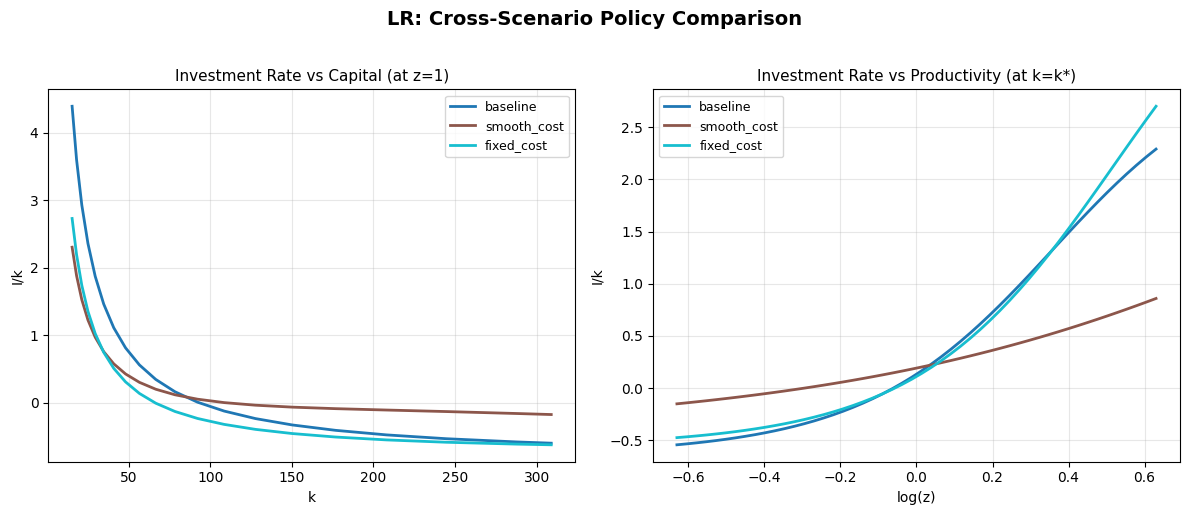

  Saved: basic_scenario_comparison_lr.png

Method: ER
  baseline: k* = 86.0158
  smooth_cost: k* = 81.5129
  fixed_cost: k* = 88.7898


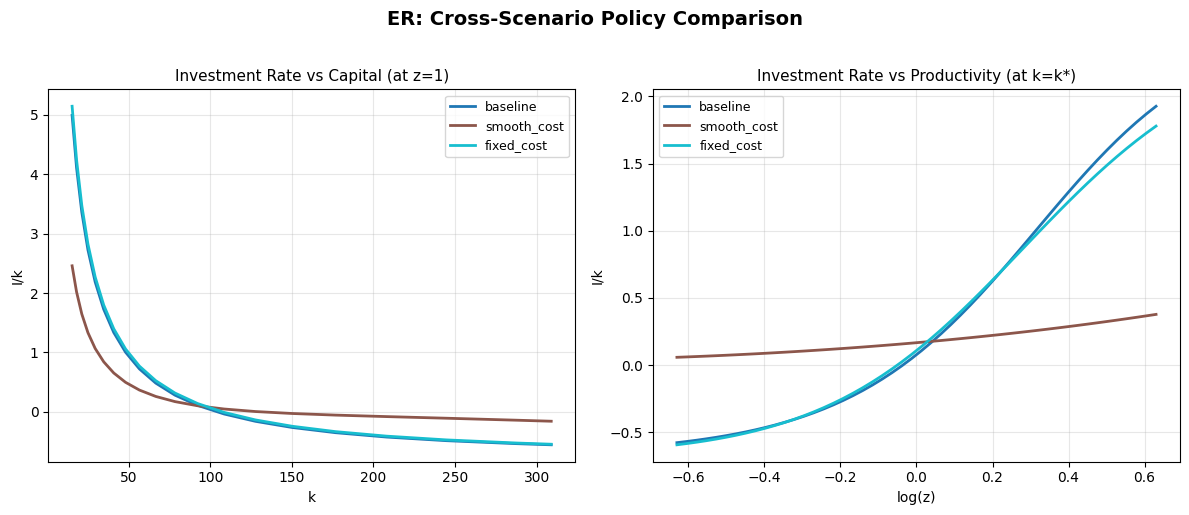

  Saved: basic_scenario_comparison_er.png

Method: BR-AC
  baseline: k* = 118.6515
  smooth_cost: k* = 91.3098
  fixed_cost: k* = 68.1412


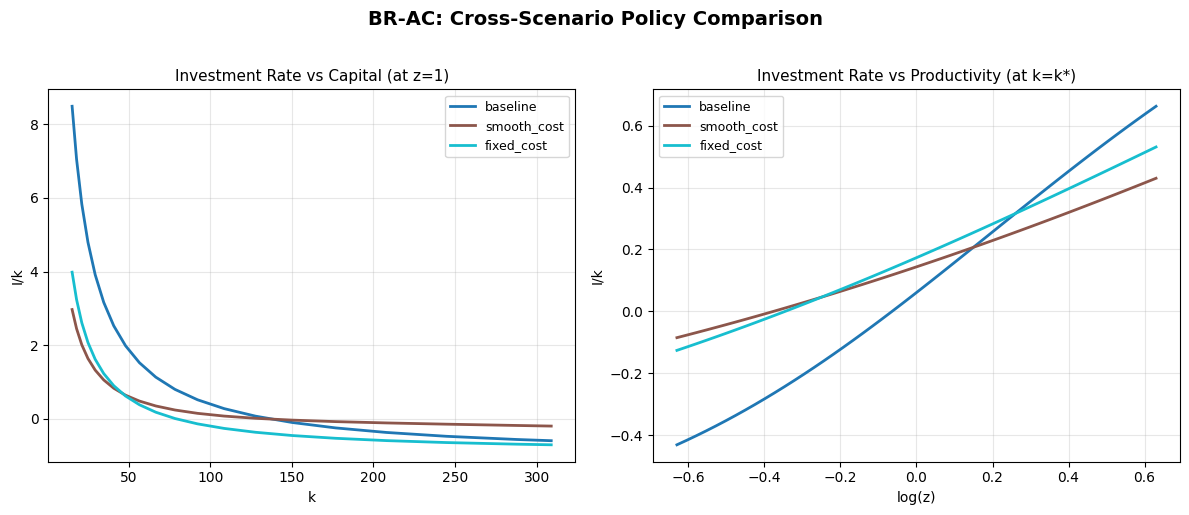

  Saved: basic_scenario_comparison_br.png

Method: BR-Reg
  baseline: k* = 89.1644
  smooth_cost: k* = 49.6218
  fixed_cost: k* = 89.7984


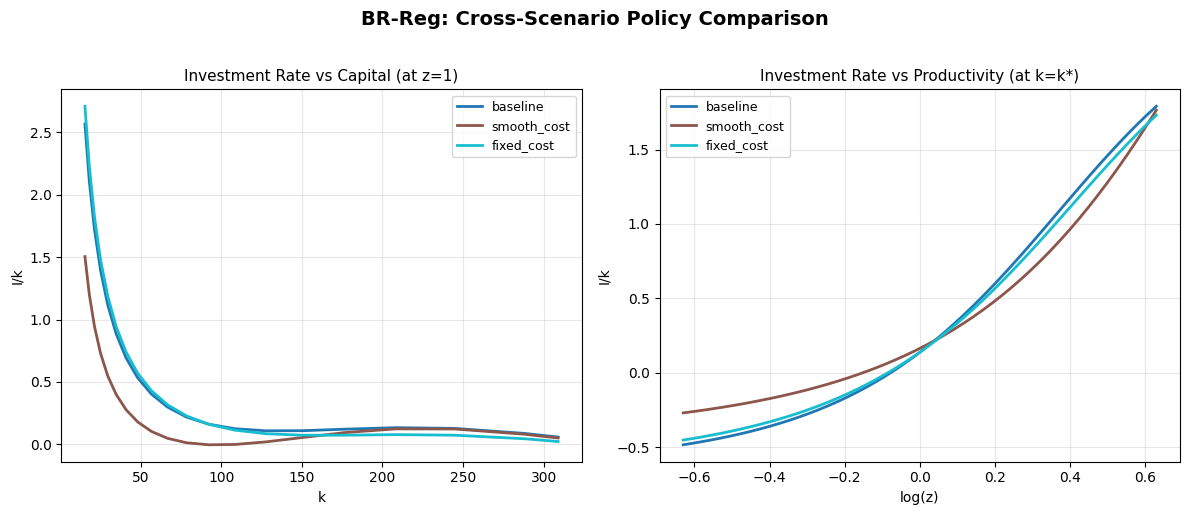

  Saved: basic_scenario_comparison_br_reg.png

Cross-scenario comparison plots complete!


In [8]:
# =============================================================================
# 3.4.4 Cross-Scenario Policy Comparison (I/k and b'/k Transformations)
# =============================================================================
# Compare transformed policies across scenarios for each training method.
# - Investment rate: I/k = k'/k - (1-δ)
# - Leverage ratio: b'/k (risky model only)

from src.utils.plotting import plot_scenario_comparison_panels
from src.utils.analysis import get_steady_state_policy, evaluate_policy

method_labels = {
    'lr': 'LR',
    'er': 'ER',
    'br': 'BR-AC',
    'br_multitask': 'BR-MT',
}

# Load delta from first scenario's saved params (should be consistent across scenarios)
first_scenario = basic_scenarios[0]
params_path = os.path.join(CHECKPOINTS_DIR, "basic", first_scenario, 'params.json')
with open(params_path, 'r') as f:
    saved_params = json.load(f)
delta = saved_params['params']['delta']

print(f"Depreciation rate (delta) loaded from {first_scenario} params: {delta}")
print("\nGenerating cross-scenario comparison plots for each method...")

for method_name in methods:
    method_label = method_labels.get(method_name, method_name.upper())

    print(f"\n{'=' * 60}")
    print(f"Method: {method_label}")
    print(f"{'=' * 60}")

    scenario_eval_datas = {}

    for scenario_name in basic_scenarios:
        scenario_results = results_basic[scenario_name]
        result = scenario_results[method_name]

        ss = get_steady_state_policy(result, k_bounds=k_bounds, logz_bounds=logz_bounds)

        grid = evaluate_policy(
            result,
            k_bounds=k_bounds,
            logz_bounds=logz_bounds,
            fixed_k_val=ss['k_star_val']
        )

        scenario_eval_datas[scenario_name] = grid
        print(f"  {scenario_name}: k* = {ss['k_star_val']:.4f}")

    fig = plot_scenario_comparison_panels(
        scenario_eval_datas,
        delta=delta,
        suptitle=f"{method_label}: Cross-Scenario Policy Comparison"
    )

    save_path = os.path.join(FIGURES_DIR, f"basic_scenario_comparison_{method_name}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  Saved: {os.path.basename(save_path)}")

print(f"\n{'=' * 60}")
print("Cross-scenario comparison plots complete!")
print(f"{'=' * 60}")



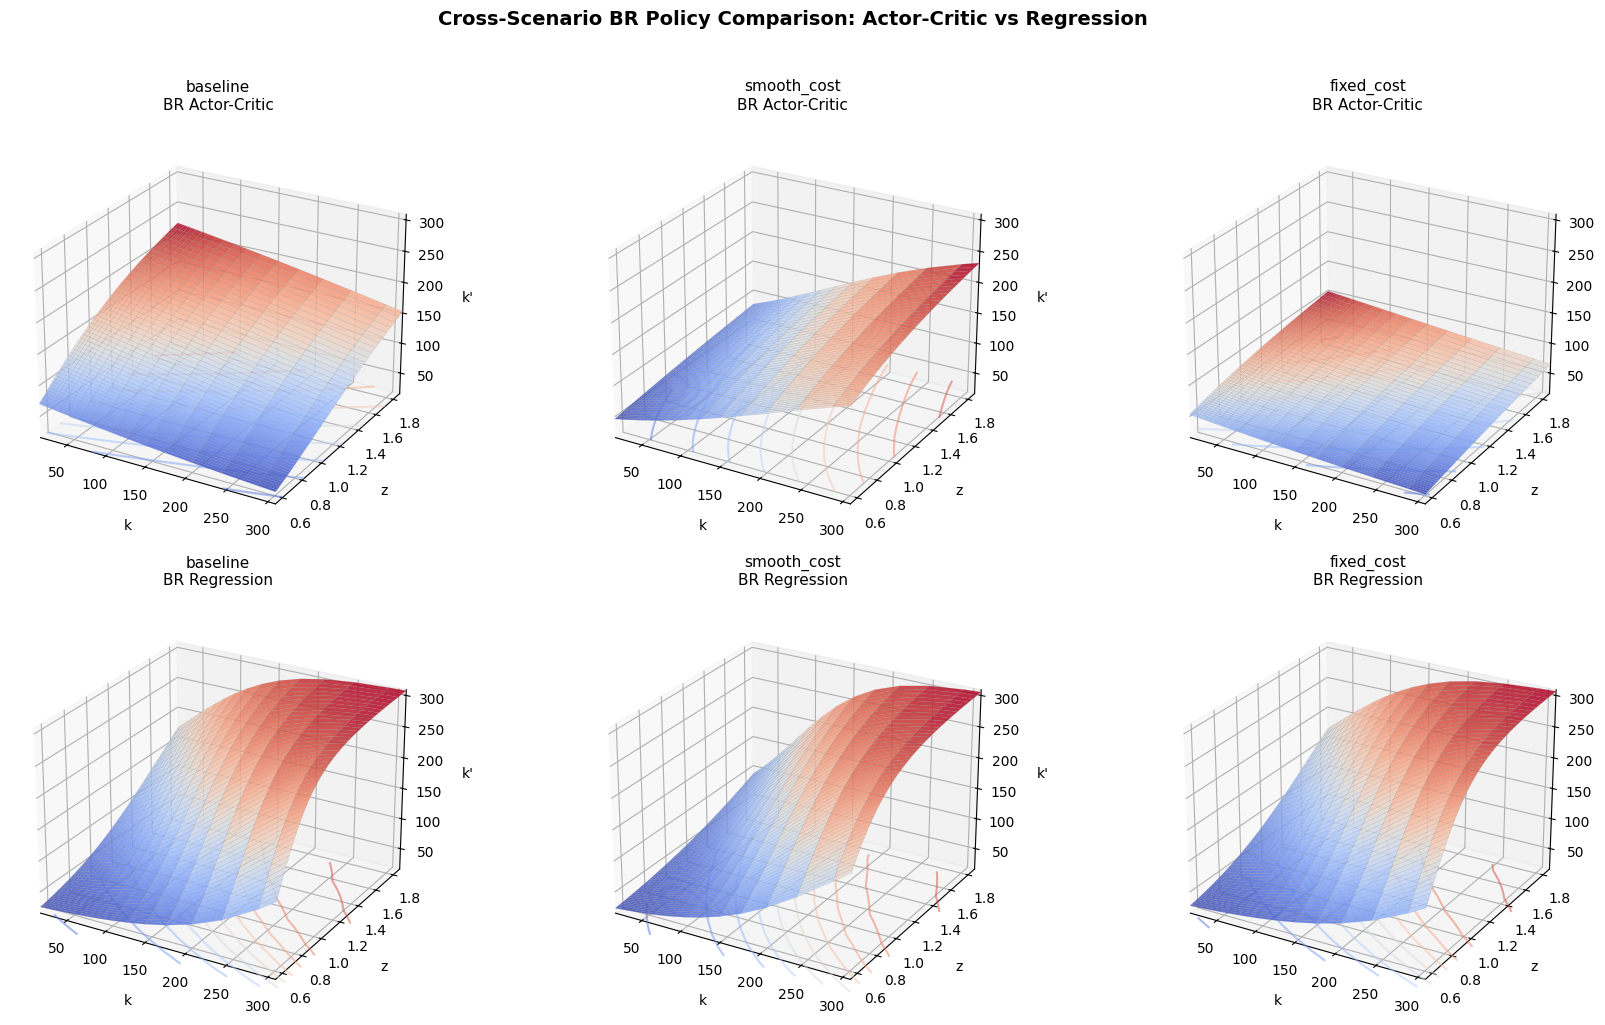

In [9]:
# =============================================================================
# 3.4.5 Cross-Scenario BR Policy Comparison (3D Surfaces: BR variants)
# =============================================================================

from src.utils.plotting import plot_3d_policy_slice
from src.utils.analysis import get_steady_state_policy, evaluate_policy

method_order = [m for m in ['br', 'br_multitask'] if m in methods]
method_labels = {
    'br': 'BR Actor-Critic',
    'br_multitask': 'BR Multitask',
}

if len(method_order) == 0:
    raise ValueError("No BR methods found in methods; cannot build BR comparison surface plots.")

n_scenarios = len(basic_scenarios)
fig = plt.figure(figsize=(6 * n_scenarios, 5 * len(method_order)))

for row_idx, method_name in enumerate(method_order):
    for col_idx, scenario_name in enumerate(basic_scenarios):
        scenario_results = results_basic[scenario_name]

        ss = get_steady_state_policy(
            scenario_results[method_name],
            k_bounds=k_bounds,
            logz_bounds=logz_bounds,
        )
        grid = evaluate_policy(
            scenario_results[method_name],
            k_bounds=k_bounds,
            logz_bounds=logz_bounds,
            fixed_k_val=ss['k_star_val'],
        )

        plot_idx = row_idx * n_scenarios + col_idx + 1
        ax = fig.add_subplot(len(method_order), n_scenarios, plot_idx, projection='3d')
        plot_3d_policy_slice(
            grid,
            y_var='k_next',
            ax=ax,
            title=f"{scenario_name}\n{method_labels.get(method_name, method_name)}",
            show_colorbar=False,
            show_contour_projection=True,
        )

fig.suptitle("Cross-Scenario BR Policy Comparison: Actor-Critic vs Multitask", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "basic_3d_cross_scenario_br_compare.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()



## 3. Risky Debt Model Analysis

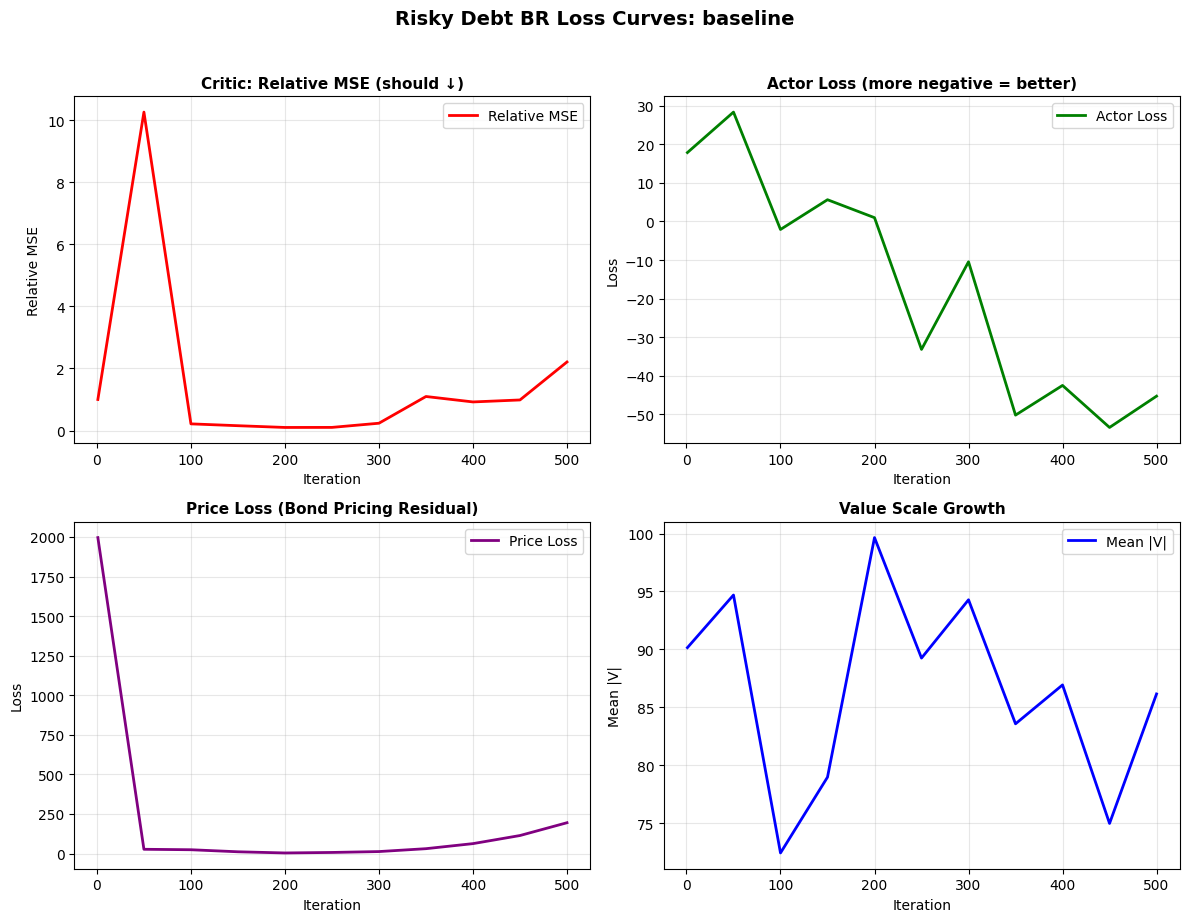


Final Training Metrics (baseline):
  Relative MSE:     2.209080
  Actor Loss:       -45.2579
  Price Loss:       194.828557
  Value Scale:      86.15
Saved: risky_loss_curves.png


In [10]:
# =============================================================================
# 3.5.1 Risky Debt BR: Loss Curves
# =============================================================================

from src.utils.plotting import plot_risky_loss_curves

# Use baseline scenario (or first available)
risky_scenario = risky_scenarios[0]
result_risky_br = results_risky[risky_scenario]

fig, summary = plot_risky_loss_curves(
    result_risky=result_risky_br,
    scenario_name=risky_scenario,
    save_path=os.path.join(FIGURES_DIR, "risky_loss_curves.png")
)
plt.show()

# Print summary statistics
print(f"\nFinal Training Metrics ({risky_scenario}):")
print(f"  Critic Loss:      {summary['loss_critic']:.6f}")
print(f"  Actor Loss:       {summary['loss_actor']:.4f}")
print(f"  Price Loss:       {summary['loss_price']:.6f}")
print(f"  Value Scale:      {summary['mean_value_scale']:.2f}")
print("Saved: risky_loss_curves.png")


Risky Debt Steady State (baseline):
  k* = 95.7343
  b* = 116.9766


/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/src/utils/plotting.py:199: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=9)


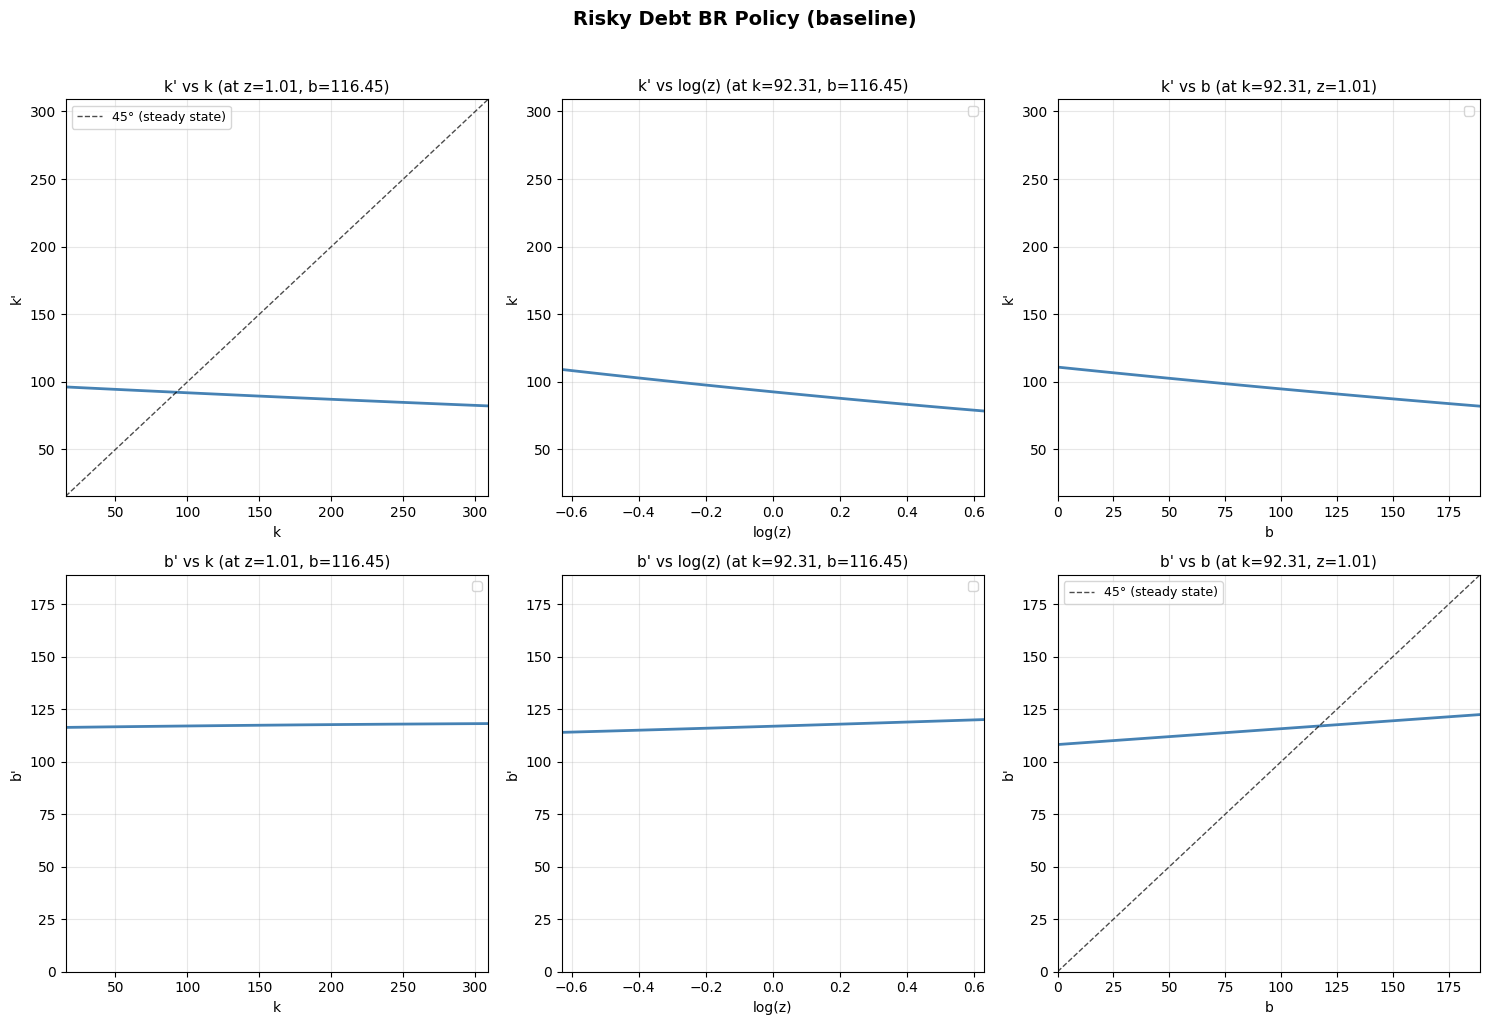

In [11]:
# =============================================================================
# 3.5.2 Risky Debt Policy Visualization (2D Panels)
# =============================================================================

from src.utils.plotting import plot_policy_slices_single
from src.utils.analysis import get_steady_state_policy, evaluate_policy

# Find steady state for risky model
ss_risky = get_steady_state_policy(result_risky_br, k_bounds=k_bounds, 
                                    logz_bounds=logz_bounds, b_bounds=b_bounds)

print(f"Risky Debt Steady State ({risky_scenario}):")
print(f"  k* = {ss_risky['k_star_val']:.4f}")
print(f"  b* = {ss_risky['b_star_val']:.4f}")

# Evaluate policy on grid
grid_risky = evaluate_policy(result_risky_br, k_bounds=k_bounds, 
                             logz_bounds=logz_bounds, b_bounds=b_bounds,
                             fixed_k_val=ss_risky['k_star_val'],
                             fixed_b_val=ss_risky['b_star_val'])

# 2x3 panel plot for risky model
fig = plot_policy_slices_single(grid_risky, suptitle=f"Risky Debt BR Policy ({risky_scenario})")
plt.savefig(os.path.join(FIGURES_DIR, "risky_br_policy.png"), dpi=150, bbox_inches='tight')
plt.show()

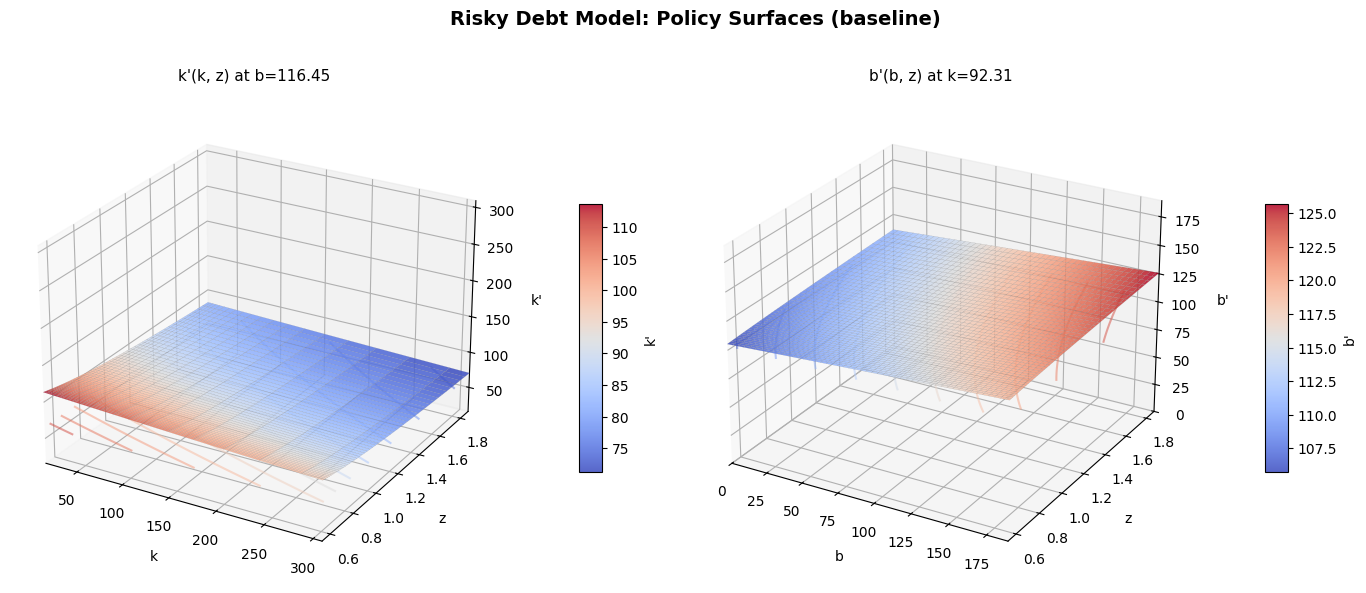

In [12]:
# =============================================================================
# 3.5.3 Risky Debt: 3D Policy Surface Visualization
# =============================================================================

from src.utils.plotting import plot_3d_policy_panels

# Risky Model 3D Surfaces
fig = plot_3d_policy_panels(grid_risky,
                            suptitle=f"Risky Debt Model: Policy Surfaces ({risky_scenario})",
                            show_contour_projection=True)
plt.savefig(os.path.join(FIGURES_DIR, "risky_3d_policies.png"), dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# =============================================================================
# 4. Summary: All Generated Figures
# =============================================================================

print("=" * 70)
print("GENERATED FIGURES")
print("=" * 70)

figures = sorted(glob.glob(os.path.join(FIGURES_DIR, "*.png")))
print(f"\nTotal figures: {len(figures)}")
print(f"Directory: {FIGURES_DIR}\n")

for fig_path in figures:
    print(f"  - {os.path.basename(fig_path)}")

GENERATED FIGURES

Total figures: 17
Directory: ../results/latest/figures

  - baseline_validation.png
  - basic_3d_cross_scenario_br_compare.png
  - basic_loss_curves_baseline.png
  - basic_loss_curves_fixed_cost.png
  - basic_loss_curves_smooth_cost.png
  - basic_policy_comparison_baseline.png
  - basic_policy_comparison_fixed_cost.png
  - basic_policy_comparison_smooth_cost.png
  - basic_scenario_comparison_br.png
  - basic_scenario_comparison_br_reg.png
  - basic_scenario_comparison_er.png
  - basic_scenario_comparison_lr.png
  - data_format_comparison.png
  - risky_3d_policies.png
  - risky_br_policy.png
  - risky_debt_diagnostics.png
  - risky_loss_curves.png
